<a href="https://colab.research.google.com/github/terrenceholden/module6-codingtask/blob/main/Module_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div>
<img src="https://babl.ai/wp-content/uploads/2022/02/logo_two.png" alt="Drawing" width="400"/>
</div>

# Introduction
This notebook is for constructing your solutions to quiz questions in Module 6 of "[Algorithms, AI, & Machine Learning: AI for AI Ethics.](https://courses.babl.ai/p/algorithms-ai-machine-learning)". Make a copy in your own drive, complete any instructions below, then share it with the instructor (sheabrown@bablai.com).


## The Dataset
  
For this exercise we'll be using the [California Housing Dataset](https://developers.google.com/machine-learning/crash-course/california-housing-data-description) as prepared by Google. We will use this dataset to train a linear regression model to predict the medisan house price in a block.

## Call the import statements

The following code imports the necessary modules.

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## Load the datasets

The following code cell loads the separate .csv files and creates the following two pandas DataFrames:

* `train_df`, which contains the training set
* `test_df`, which contains the test set

Don't worry, for the moment, what a "pandas DataFrame" is, except that it's a nice way to store and retrieve data.

In [ ]:
#@title
# Load the training and testing data, then reshuffle the training data.
# ----------------------------------------------------------------------
train_df = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv")
test_df = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/california_housing_test.csv")
train_df = train_df.sample(frac=1, random_state=5) #train_df.reindex(np.random.permutation(train_df.index)) # shuffle the training set


## Normalize feature values

If you want to use more than one feature to train a model, having wildly different ranges of values can be problematic. If you look at the data from the California Housing Dataset, the different columns have values that are quite different in scale, so we will normalize each column into a **Z-score**.

A **Z-score** is the number of standard deviations from the mean for a particular raw value. For example, consider a feature having the following characteristics:

  * The mean is 60.
  * The standard deviation is 10.

The raw value 75 would have a Z-score of +1.5:

```
  Z-score = (75 - 60) / 10 = +1.5
```

The raw value 38 would have a Z-score of -2.2:

```
  Z-score = (38 - 60) / 10 = -2.2
```


In [ ]:
#@title
# Calculate the Z-scores of each column in the training set and
# write those Z-scores into a new pandas DataFrame named train_df_norm.
train_df_mean = train_df.mean()
train_df_std = train_df.std()
train_df_norm = (train_df - train_df_mean)/train_df_std


# Calculate the Z-scores of each column in the test set and
# write those Z-scores into a new pandas DataFrame named test_df_norm.
test_df_mean = test_df.mean()
test_df_std  = test_df.std()
test_df_norm = (test_df - test_df_mean)/test_df_std

# Create a new column that will hold a binary value; 0 of the median house value is below a threshold and 1 if it's above.
# --------------------------------------------------------------------------------------------------------------------------
threshold = 265000 # This is the 75th percentile for median house values.
train_df_norm["median_house_value_is_high"] = (train_df['median_house_value'] > threshold).astype(int)
test_df_norm["median_house_value_is_high"] = (test_df['median_house_value'] > threshold).astype(int)

# Examine some of the values of the normalized training set. Notice that most
# Z-scores fall between -2 and +2.
train_df_norm.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,median_house_value_is_high
7704,0.589531,-0.685537,1.383231,-0.015901,0.127139,-0.326326,0.217877,-0.296557,0.880288,1
12157,-0.941514,1.396491,1.383231,-0.406278,-0.067404,-0.292349,-0.044788,-1.475287,-1.183794,0
14112,-1.245728,0.806973,0.191520,-0.389305,-0.613075,-0.485754,-0.570117,2.188668,1.504513,1
8534,0.529686,-0.662143,0.588757,-0.453068,-0.544273,-0.533669,-0.502501,0.882486,0.074140,0
5965,0.674312,-0.783790,1.144889,-0.524629,-0.285673,0.258244,-0.159216,-1.058340,-0.363852,0


## Data exploration
If you want, you can explore correlations between the features of the dataset, as well as correlations between the target variable `median_house_value` and other features. It's best to do this with the original, un-normalized dataset, so you can see the actual values.

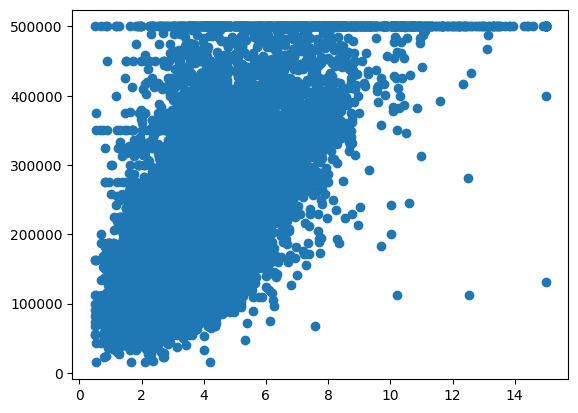

In [ ]:
plt.scatter(train_df['median_income'],train_df['median_house_value'])

## Feature extraction

We will now extract the feature values from the normalized dataframe (the one with **Z-scores**) and put them into Numpy arrays, where the columns represent the features, and each row is a sigle training (or test) sample.

We will also extract the target values for the training and test datasets.

In [ ]:
data = train_df_norm[['longitude','longitude','total_rooms','total_bedrooms','population','households','median_income']].to_numpy()
test_data = test_df_norm[['longitude','longitude','total_rooms','total_bedrooms','population','households','median_income']].to_numpy()
y = train_df['median_house_value'].to_numpy()
y_test = test_df['median_house_value'].to_numpy()


# Exercises
---
Now we can start to use these data to answer questions in the quizzes and for Exercise \#2.

## Linear Models

We're going to explore linear networks, which are ways of making predictions that are a linear function of the input features. If $\hat{y}$ is the prediction that the model is trying to make, and $x$ is the feature vector, then a linear model takes the form:

\begin{equation} \hat{y} = w^{\intercal} x +b
\end{equation}

where $w$ is are weights and $b$ is a constant (slope intercept form), and these are the values that one tries to find when 'training' the predictor. The exact form that $w$ and $b$ take depends on whether the $\hat{y}$ is a single number or a vector (see the lectures).

### Part 1: Modeling
Let's now write a simple function that will take an input feature vector $x$, a weight vector $w$, and a constant $b$ and execute the above linear equation. You can make use of `np.dot()` or `np.sum(,axis=0)` to do this.




In [ ]:
def predict(x,w,b):
  # Put your code here
  return pred

# Test it out on these. You should get about 1.88529
w = np.ones(len(data[0])) # We're using a row from our training dataset to get the correct length of the weight vector.
b = 1.0
x = data[0] # We're using a row from our training dataset
print(predict(x,w,b))

[ 0.58953124  0.58953124 -0.01590149  0.12713937 -0.32632572  0.21787651
 -0.29655749]
[1. 1. 1. 1. 1. 1. 1.]
1.0
1.8852936637566882


Note that the above function has random values for $w$ and $b$, so does not actually predict anything that we're interested in. The task of finding the correct values of that will give us a useful inference is called *learning*.

## Part 2: Inference

If your inference task is linear regression, where the output is a real number, the above equation works perfectly. However, if you are doing binary classification (see the lectures), you will want to force your prediction to be a probability of being in a certain class, so the output of linear network, which could be a real number of any value, should be mapped to a value between [0,1]. This can be accomplished by using the *sigmoid function*. As is often done in machine-learning instructional material, we'll also denote this with the symbol $\sigma(x)$. The equation is:

\begin{equation} \sigma(x) = \frac{1}{1+e^{-x}}
\end{equation}

Similarly, if you're interested in doing multi-class classification, you'll need to use the softmax function which takes a vector instead of a number as an argument, and returns another vector of probabilites:

\begin{equation}
\sigma(x_i)= \frac{e^{x_i}}{\Sigma_{j} e^{x_j}}
\end{equation}

So in order to make an inference using a linear model, the equations look slightly different:

\begin{array}{c}
\hat{y} = w^{\intercal} x +b &\text{(linear regression)}\\
\hat{y} = \sigma (w^{\intercal} x +b) & \text{(binary classification  with  a sigmoid function)} \\
\hat{y} = \sigma (w^{\intercal} x +b) & \text{(multi-class  classification  with  a  softmax function)}
\end{array}


Below you should write a function that will take a number as an input and map it to a probability using the sigmoid function. We won't use this below, but there will be a quiz question on it.

In [ ]:
def sigmoid(y_hat):
  # Replace my code below with the correct code for a sigmoid function
  sig = y_hat
  return sig

# Try it out on the number x=2. The answer should be about 0.880797
print(sigmoid(2))

2


## Part 3: Learning

There are a number of ways that we can learn from data, but in this case we will use *supervised learning*. We have a training dataset that we collected above that has feature vectors as well as the corresponding target values, $y$, which in this case will be the `median_house_price`. We'll be using the equations we discussed in lecture for stocastic gradient descent:

\begin{equation} w = w_{old} - \alpha \nabla_w Loss(x,y,w,b) \\
b = b_{old} - \alpha \nabla_b Loss(x,y,w,b)
\end{equation}

Below is an implementation of stocastic gradient descent using the predict() fuction you wrote earlier.

In [ ]:
length = len(data[0])
w = np.zeros(length)
b = np.random.random()
print(w)
print(b)
n = len(y)
L = 0.001 # This is the learning rate
epochs = 10

# Performing Stocastic Gradient Descent
for i in range(len(y)):
    y_pred = predict(data[i],w,b)  # The current predicted value of y
    d_w = (-2) * data[i]*(y[i] - y_pred)  # Derivative wrt w
    d_b = (-2) * (y[i] - y_pred)  # Derivative wrt b
    w = w - L * d_w  # Update w
    b = b - L * d_b  # Update b


After running the above cell, check to see how the predict() function does at predicting house prices from the test dataset. Remember, this dataset was not used to train the algorithm.

## Exercise 2

a) In the cell below, write code that will test what the average root-mean-squared error is for the predict() function:

\begin{equation}
RMSE = \sqrt{\frac{\Sigma_i (y_i - \hat{y_i})^2}{N}},
\end{equation}

where the sum is over all the $N$ samples in the test dataset.

b) Copy the above cell and modify it so that you are looping through the all the samples in the training data more than one time (e.g., 3 times). Does the $RMSE$ get better or worse when you loop through the data more than once?

In [ ]:
# Test it out on one of the test data
print(predict(test_data[2],w,b))
print(y_test[2])